In [1]:
import numpy as np
import matplotlib.pyplot as plt
import Tdoa
import Aoa
import Hybrid
import Comm as com
import Multipath as mp
import importlib
import util

In [2]:
plt.rcParams.update({
    "font.size": 13,
    "font.family": "serif",
    "mathtext.fontset": "cm",  # This gives the LaTeX look to math text
    "axes.edgecolor": "black", # Black bounding box
    "axes.linewidth": 0.8
})

In [4]:
num_rx = 4

In [36]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

tdoa_errors_4 = []
tdoa_errors_4_bis = []
tdoa_errors_6 = []
tdoa_errors_6_bis = []
tdoa_errors_8 = []
tdoa_errors_8_bis = []

tdoa_positions_4 = []
tdoa_positions_6 = []
tdoa_positions_8 = []
tdoa_positions_4_bis = []
tdoa_positions_6_bis = []
tdoa_positions_8_bis = []

len_tdoa_4 = []
len_tdoa_6 = []
len_tdoa_8 = []

for i in range(8):
    for j in range(5):
        for num_rx in [4, 6, 8]:
            filename = f"Large{num_rx}/taps_estimates_{i}_{j}.csv"
            TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

            for iter in range(10):
                
                taus_hat = data[f'{iter}']['delays']
                angles_hat = data[f'{iter}']['angles']

                first_toas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                    first_toas[RX_idx] = first_toa

                first_aoas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

                # TDOA localization using first path
                TdoaLocalizer = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)
                position_estimate_tdoa = TdoaLocalizer.localize()
                position_estimate_tdoa_bis = TdoaLocalizer.localize_least_squares()
                if num_rx == 4:
                    len_tdoa_4.append(len(TdoaLocalizer.tdoas))
                    tdoa_errors_4.append(np.linalg.norm(position_estimate_tdoa - TX_position[:2]))
                    tdoa_errors_4_bis.append(np.linalg.norm(position_estimate_tdoa_bis - TX_position[:2]))
                    tdoa_positions_4.append(position_estimate_tdoa)
                    tdoa_positions_4_bis.append(position_estimate_tdoa_bis)
                elif num_rx == 6:
                    len_tdoa_6.append(len(TdoaLocalizer.tdoas))
                    tdoa_errors_6.append(np.linalg.norm(position_estimate_tdoa - TX_position[:2]))
                    tdoa_errors_6_bis.append(np.linalg.norm(position_estimate_tdoa_bis - TX_position[:2]))
                    tdoa_positions_6.append(position_estimate_tdoa)
                    tdoa_positions_6_bis.append(position_estimate_tdoa_bis)
                elif num_rx == 8:
                    len_tdoa_8.append(len(TdoaLocalizer.tdoas))
                    tdoa_errors_8.append(np.linalg.norm(position_estimate_tdoa - TX_position[:2]))
                    tdoa_errors_8_bis.append(np.linalg.norm(position_estimate_tdoa_bis - TX_position[:2]))
                    tdoa_positions_8.append(position_estimate_tdoa)
                    tdoa_positions_8_bis.append(position_estimate_tdoa_bis)


In [23]:

# count the number of occurrences of each number of TDOAs for each number of RXs
from collections import Counter
counter_4 = Counter(len_tdoa_4)
counter_6 = Counter(len_tdoa_6)
counter_8 = Counter(len_tdoa_8)

print("TDOA counts for 4 RXs:", counter_4)
print("TDOA counts for 6 RXs:", counter_6)
print("TDOA counts for 8 RXs:", counter_8)

TDOA counts for 4 RXs: Counter({3: 198, 2: 192, 1: 10})
TDOA counts for 6 RXs: Counter({4: 251, 5: 100, 3: 39, 2: 10})
TDOA counts for 8 RXs: Counter({6: 213, 7: 100, 5: 67, 4: 20})


In [27]:
# RMSE

position_bounds = (-10, 10, -7.5, 7.5)
def is_within_bounds(position):
    return position[0] >= position_bounds[0] and position[0] <= position_bounds[1] and position[1] >= position_bounds[2] and position[1] <= position_bounds[3]

# Remove nan values from the error lists
tdoa_errors_filtered_4 = []
tdoa_errors_filtered_6 = []
tdoa_errors_filtered_8 = []
tdoa_errors_bis_filtered_4 = []
tdoa_errors_bis_filtered_6 = []
tdoa_errors_bis_filtered_8 = []
for i in range(len(tdoa_errors_4)):
    if not np.isnan(tdoa_errors_4[i]) and tdoa_errors_4[i] < 15:
        tdoa_errors_filtered_4.append(tdoa_errors_4[i])
    if not np.isnan(tdoa_errors_6[i]) and tdoa_errors_6[i] < 15:
        tdoa_errors_filtered_6.append(tdoa_errors_6[i])
    if not np.isnan(tdoa_errors_8[i]) and tdoa_errors_8[i] < 15:
        tdoa_errors_filtered_8.append(tdoa_errors_8[i])
    if not np.isnan(tdoa_errors_4_bis[i]) and tdoa_errors_4_bis[i] < 15:
        tdoa_errors_bis_filtered_4.append(tdoa_errors_4_bis[i])
    if not np.isnan(tdoa_errors_6_bis[i]) and tdoa_errors_6_bis[i] < 15:
        tdoa_errors_bis_filtered_6.append(tdoa_errors_6_bis[i])
    if not np.isnan(tdoa_errors_8_bis[i]) and tdoa_errors_8_bis[i] < 15:
        tdoa_errors_bis_filtered_8.append(tdoa_errors_8_bis[i])

rmse_tdoa_4 = np.sqrt(np.mean(np.array(tdoa_errors_filtered_4)**2))
rmse_tdoa_6 = np.sqrt(np.mean(np.array(tdoa_errors_filtered_6)**2))
rmse_tdoa_8 = np.sqrt(np.mean(np.array(tdoa_errors_filtered_8)**2))
rmse_tdoa_bis_4 = np.sqrt(np.mean(np.array(tdoa_errors_bis_filtered_4)**2))
rmse_tdoa_bis_6 = np.sqrt(np.mean(np.array(tdoa_errors_bis_filtered_6)**2))
rmse_tdoa_bis_8 = np.sqrt(np.mean(np.array(tdoa_errors_bis_filtered_8)**2))

print(f"RMSE TDOA (closed-form) - 4 RXs: {rmse_tdoa_4:.2f} m")
print(f"RMSE TDOA (closed-form) - 6 RXs: {rmse_tdoa_6:.2f} m")
print(f"RMSE TDOA (closed-form) - 8 RXs: {rmse_tdoa_8:.2f} m")
print(f"RMSE TDOA (least-squares) - 4 RXs: {rmse_tdoa_bis_4:.2f} m")
print(f"RMSE TDOA (least-squares) - 6 RXs: {rmse_tdoa_bis_6:.2f} m")
print(f"RMSE TDOA (least-squares) - 8 RXs: {rmse_tdoa_bis_8:.2f} m")

print(f"Ratio of valid localizations (closed-form) - 4 RXs: {len(tdoa_errors_filtered_4)}/{len(tdoa_errors_4)}")
print(f"Ratio of valid localizations (closed-form) - 6 RXs: {len(tdoa_errors_filtered_6)}/{len(tdoa_errors_6)}")
print(f"Ratio of valid localizations (closed-form) - 8 RXs: {len(tdoa_errors_filtered_8)}/{len(tdoa_errors_8)}")
print(f"Ratio of valid localizations (least-squares) - 4 RXs: {len(tdoa_errors_bis_filtered_4)}/{len(tdoa_errors_4_bis)}")
print(f"Ratio of valid localizations (least-squares) - 6 RXs: {len(tdoa_errors_bis_filtered_6)}/{len(tdoa_errors_6_bis)}")
print(f"Ratio of valid localizations (least-squares) - 8 RXs: {len(tdoa_errors_bis_filtered_8)}/{len(tdoa_errors_8_bis)}")

RMSE TDOA (closed-form) - 4 RXs: 3.74 m
RMSE TDOA (closed-form) - 6 RXs: 3.10 m
RMSE TDOA (closed-form) - 8 RXs: 3.37 m
RMSE TDOA (least-squares) - 4 RXs: 3.19 m
RMSE TDOA (least-squares) - 6 RXs: 5.13 m
RMSE TDOA (least-squares) - 8 RXs: 5.22 m
Ratio of valid localizations (closed-form) - 4 RXs: 316/400
Ratio of valid localizations (closed-form) - 6 RXs: 336/400
Ratio of valid localizations (closed-form) - 8 RXs: 359/400
Ratio of valid localizations (least-squares) - 4 RXs: 290/400
Ratio of valid localizations (least-squares) - 6 RXs: 327/400
Ratio of valid localizations (least-squares) - 8 RXs: 306/400


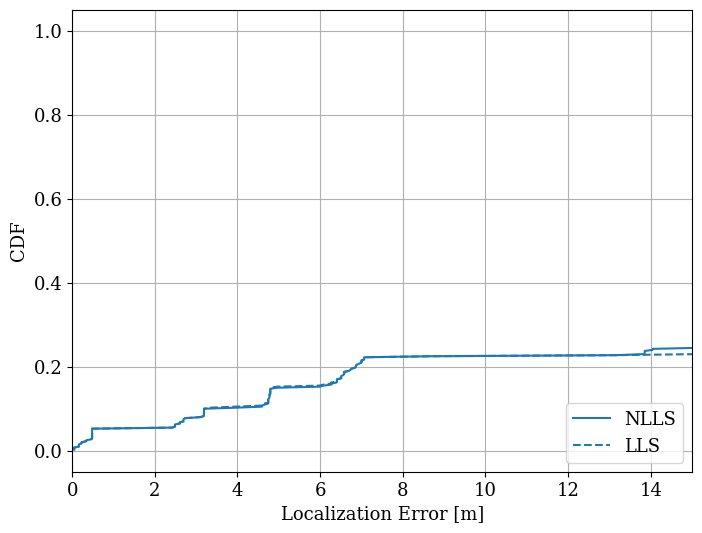

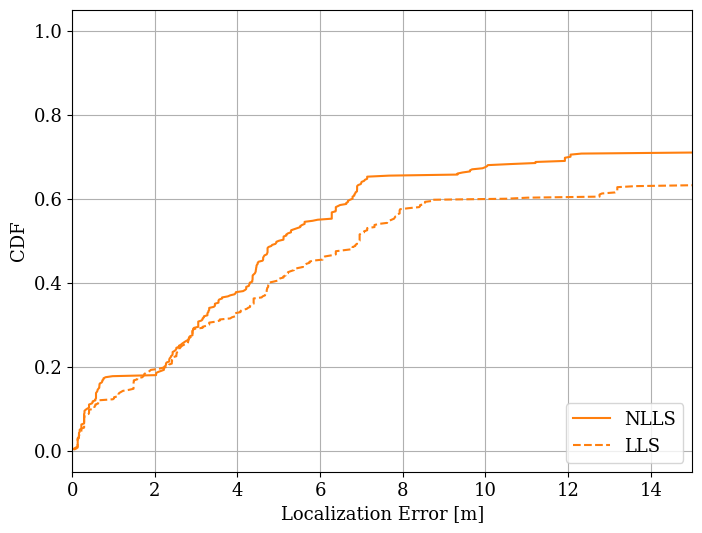

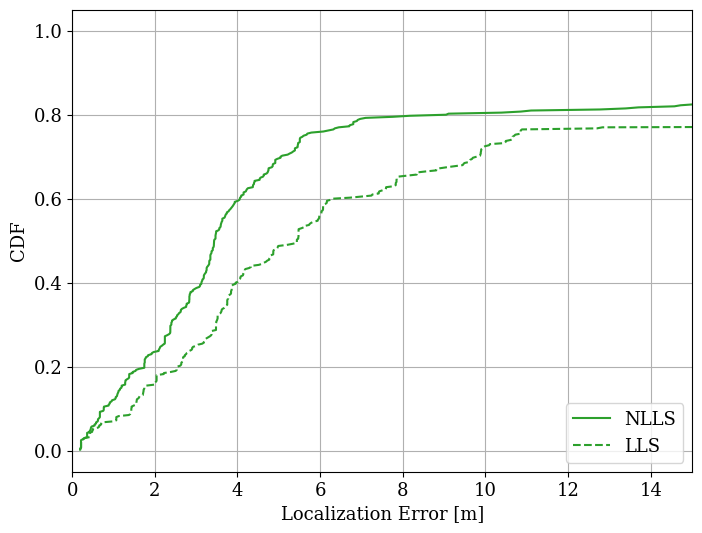

In [37]:
tdoa_errors_4_plot = np.sort(np.array(tdoa_errors_4))
tdoa_errors_4_bis_plot = np.sort(np.array(tdoa_errors_4_bis))
tdoa_errors_6_plot = np.sort(np.array(tdoa_errors_6))
tdoa_errors_6_bis_plot = np.sort(np.array(tdoa_errors_6_bis))
tdoa_errors_8_plot = np.sort(np.array(tdoa_errors_8))
tdoa_errors_8_bis_plot = np.sort(np.array(tdoa_errors_8_bis))


cumulative = np.arange(1, len(tdoa_errors_4_plot) + 1) / len(tdoa_errors_4_plot)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(tdoa_errors_4_plot, cumulative, label='NLLS', color='tab:blue')
ax.plot(tdoa_errors_4_bis_plot, cumulative, label='LLS', linestyle='--', color='tab:blue')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 15)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
# plt.savefig('tdoa_cdf_small_4.pdf', bbox_inches='tight')
plt.show()


fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(tdoa_errors_6_plot, cumulative, label='NLLS', color='tab:orange')
ax.plot(tdoa_errors_6_bis_plot, cumulative, label='LLS', linestyle='--', color='tab:orange')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 15)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
# plt.savefig('tdoa_cdf_small_6.pdf', bbox_inches='tight')
plt.show()


fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(tdoa_errors_8_plot, cumulative, label='NLLS', color='tab:green')
ax.plot(tdoa_errors_8_bis_plot, cumulative, label='LLS', linestyle='--', color='tab:green')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 15)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
# plt.savefig('tdoa_cdf_small_8.pdf', bbox_inches='tight')
plt.show()

In [40]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

aoa_errors_4 = []
aoa_errors_6 = [] = []
aoa_errors_8 = [] = []


for i in range(8):
    for j in range(5):
        for num_rx in [4, 6, 8]:
            filename = f"Large{num_rx}/taps_estimates_{i}_{j}.csv"
            TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

            for iter in range(10):
                
                taus_hat = data[f'{iter}']['delays']
                angles_hat = data[f'{iter}']['angles']

                first_toas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                    first_toas[RX_idx] = first_toa

                first_aoas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

                # AOA localization using first path
                AoALocalizer = Aoa.AoaLocalization(first_aoas, [rx[:2] for rx in RX_positions])
                position_estimate_aoa = AoALocalizer.localize_least_squares()
                if num_rx == 4:
                    aoa_errors_4.append(np.linalg.norm(position_estimate_aoa - TX_position[:2]))
                elif num_rx == 6:
                    aoa_errors_6.append(np.linalg.norm(position_estimate_aoa - TX_position[:2]))
                elif num_rx == 8:
                    aoa_errors_8.append(np.linalg.norm(position_estimate_aoa - TX_position[:2]))


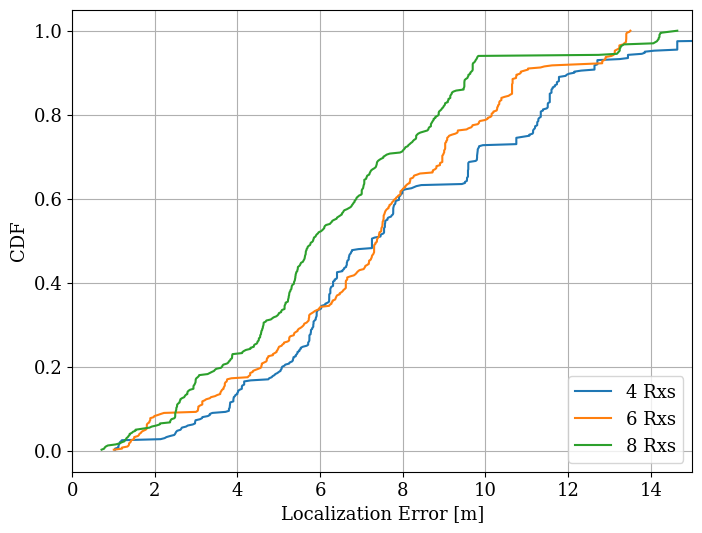

In [41]:
aoa_errors_4_plot = np.sort(np.array(aoa_errors_4))
aoa_errors_6_plot = np.sort(np.array(aoa_errors_6))
aoa_errors_8_plot = np.sort(np.array(aoa_errors_8))


cumulative = np.arange(1, len(aoa_errors_4_plot) + 1) / len(aoa_errors_4_plot)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(aoa_errors_4_plot, cumulative, label='4 Rxs', color='tab:blue')
ax.plot(aoa_errors_6_plot, cumulative, label='6 Rxs', linestyle='-', color='tab:orange')
ax.plot(aoa_errors_8_plot, cumulative, label='8 Rxs', linestyle='-', color='tab:green')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 15)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
plt.savefig('aoa_cdf_large.pdf', bbox_inches='tight')
plt.show()

In [62]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

hybrid_errors_4 = []
hybrid_errors_6 = []
hybrid_errors_8 = []


for i in range(8):
    for j in range(5):
        for num_rx in [4, 6, 8]:
            filename = f"Small{num_rx}/taps_estimates_{i}_{j}.csv"
            TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

            for iter in range(10):
                
                taus_hat = data[f'{iter}']['delays']
                angles_hat = data[f'{iter}']['angles']

                first_toas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                    first_toas[RX_idx] = first_toa

                first_aoas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

                # Hybrid localization using first path
                HybridLocalizer = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
                position_estimate_hybrid = HybridLocalizer.localize()
                if num_rx == 4:
                    hybrid_errors_4.append(np.linalg.norm(position_estimate_hybrid - TX_position[:2]))
                elif num_rx == 6:
                    hybrid_errors_6.append(np.linalg.norm(position_estimate_hybrid - TX_position[:2]))
                elif num_rx == 8:
                    hybrid_errors_8.append(np.linalg.norm(position_estimate_hybrid - TX_position[:2]))


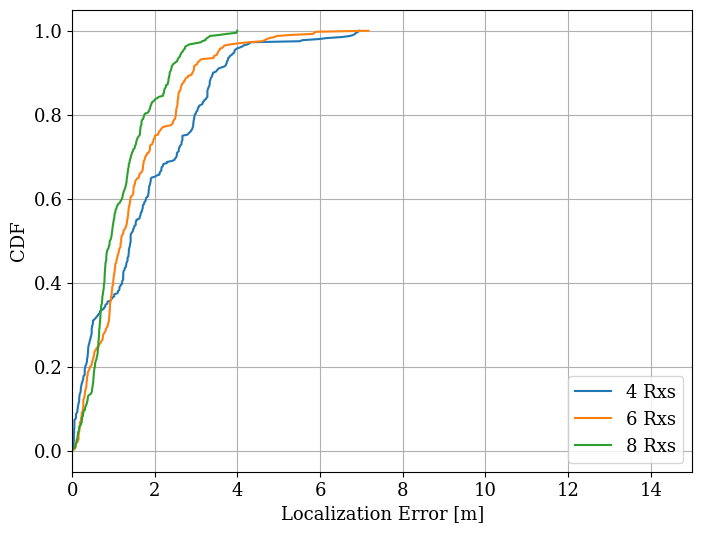

In [63]:
hybrid_errors_4_plot = np.sort(np.array(hybrid_errors_4))
hybrid_errors_6_plot = np.sort(np.array(hybrid_errors_6))
hybrid_errors_8_plot = np.sort(np.array(hybrid_errors_8))


cumulative = np.arange(1, len(hybrid_errors_4_plot) + 1) / len(hybrid_errors_4_plot)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(hybrid_errors_4_plot, cumulative, label='4 Rxs', color='tab:blue')
ax.plot(hybrid_errors_6_plot, cumulative, label='6 Rxs', linestyle='-', color='tab:orange')
ax.plot(hybrid_errors_8_plot, cumulative, label='8 Rxs', linestyle='-', color='tab:green')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 15)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
# plt.savefig('hybrid_cdf_large.pdf', bbox_inches='tight')
plt.show()

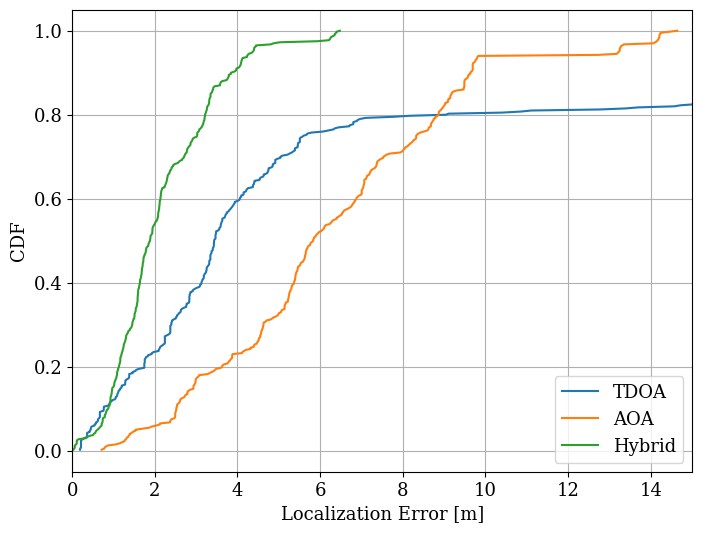

In [ ]:

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(tdoa_errors_8_plot, cumulative, label='TDOA', color='tab:blue')
ax.plot(aoa_errors_8_plot, cumulative, label='AOA', color='tab:orange')
ax.plot(hybrid_errors_8_plot, cumulative, label='Hybrid', color='tab:green')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 15)
ax.set_ylim(-0.05, 1.05)

ax.legend(loc='lower right')
ax.grid()
# plt.savefig('comparison_cdf_large_8.pdf', bbox_inches='tight')
plt.show()

In [70]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

hybrid_ransac_errors_4 = []
hybrid_ransac_errors_6 = []
hybrid_ransac_errors_8 = []


for i in range(8):
    for j in range(5):
        for num_rx in [4, 6, 8]:
            filename = f"Large{num_rx}/taps_estimates_{i}_{j}.csv"
            TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

            for iter in range(10):
                
                taus_hat = data[f'{iter}']['delays']
                angles_hat = data[f'{iter}']['angles']

                first_toas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                    first_toas[RX_idx] = first_toa

                first_aoas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

                # Hybrid localization using first path
                HybridLocalizer = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
                position_estimate_hybrid_ransac = HybridLocalizer.localize_ransac(100, threshold=0.5)
                if num_rx == 4:
                    hybrid_ransac_errors_4.append(np.linalg.norm(position_estimate_hybrid_ransac - TX_position[:2]))
                elif num_rx == 6:
                    hybrid_ransac_errors_6.append(np.linalg.norm(position_estimate_hybrid_ransac - TX_position[:2]))
                elif num_rx == 8:
                    hybrid_ransac_errors_8.append(np.linalg.norm(position_estimate_hybrid_ransac - TX_position[:2]))


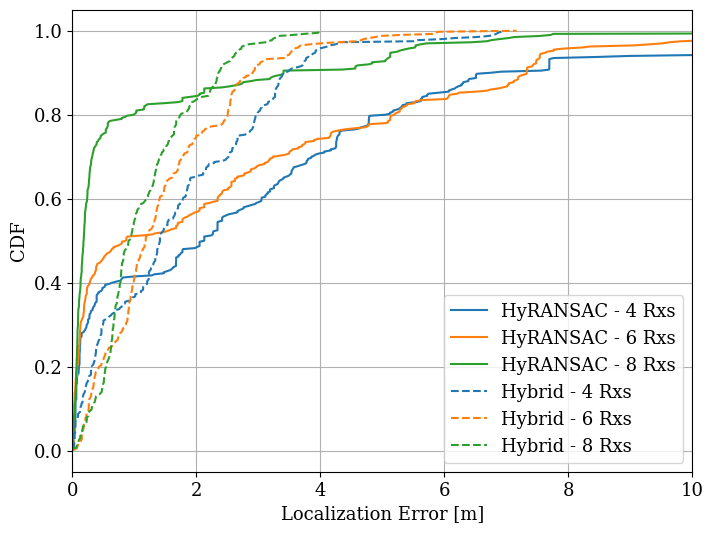

In [74]:
hybrid_ransac_errors_4_plot = np.sort(np.array(hybrid_ransac_errors_4))
hybrid_ransac_errors_6_plot = np.sort(np.array(hybrid_ransac_errors_6))
hybrid_ransac_errors_8_plot = np.sort(np.array(hybrid_ransac_errors_8))


cumulative = np.arange(1, len(hybrid_ransac_errors_4_plot) + 1) / len(hybrid_ransac_errors_4_plot)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(hybrid_ransac_errors_4_plot, cumulative, label='HyRANSAC - 4 Rxs', color='tab:blue')
ax.plot(hybrid_ransac_errors_6_plot, cumulative, label='HyRANSAC - 6 Rxs', linestyle='-', color='tab:orange')
ax.plot(hybrid_ransac_errors_8_plot, cumulative, label='HyRANSAC - 8 Rxs', linestyle='-', color='tab:green')
ax.plot(hybrid_errors_4_plot, cumulative, label='Hybrid - 4 Rxs', linestyle='--', color='tab:blue')
ax.plot(hybrid_errors_6_plot, cumulative, label='Hybrid - 6 Rxs', linestyle='--', color='tab:orange')
ax.plot(hybrid_errors_8_plot, cumulative, label='Hybrid - 8 Rxs', linestyle='--', color='tab:green')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 10)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
# plt.savefig('hybrid_ransac_cdf_small.pdf', bbox_inches='tight')
plt.show()

In [46]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

hybrid_ransac_errors_4 = [[], [], [], [], []]
hybrid_ransac_errors_6 = [[], [], [], [], []]
hybrid_ransac_errors_8= [[], [], [], [], []]

for i in range(8):
    for j in range(5):
        for num_rx in [4, 6, 8]:
            filename = f"Large{num_rx}/taps_estimates_{i}_{j}.csv"
            TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

            for iter in range(10):
                
                taus_hat = data[f'{iter}']['delays']
                angles_hat = data[f'{iter}']['angles']

                first_toas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                    first_toas[RX_idx] = first_toa

                first_aoas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

                # Hybrid localization using first path
                HybridLocalizer = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
                for t, threshold in enumerate([0.1, 0.25, 0.5, 1.0, 2.0]):
                    position_estimate_hybrid_ransac = HybridLocalizer.localize_ransac(threshold=threshold)
                    if num_rx == 4:
                        hybrid_ransac_errors_4[t].append(np.linalg.norm(position_estimate_hybrid_ransac - TX_position[:2]))
                    elif num_rx == 6:
                        hybrid_ransac_errors_6[t].append(np.linalg.norm(position_estimate_hybrid_ransac - TX_position[:2]))
                    elif num_rx == 8:
                        hybrid_ransac_errors_8[t].append(np.linalg.norm(position_estimate_hybrid_ransac - TX_position[:2]))


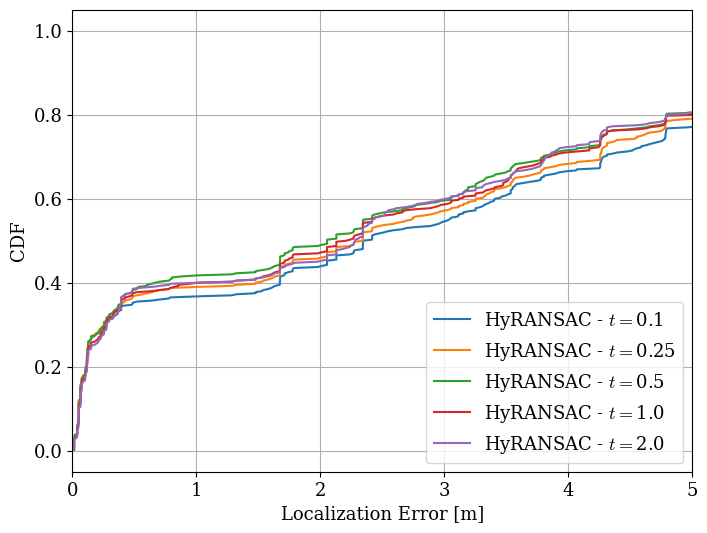

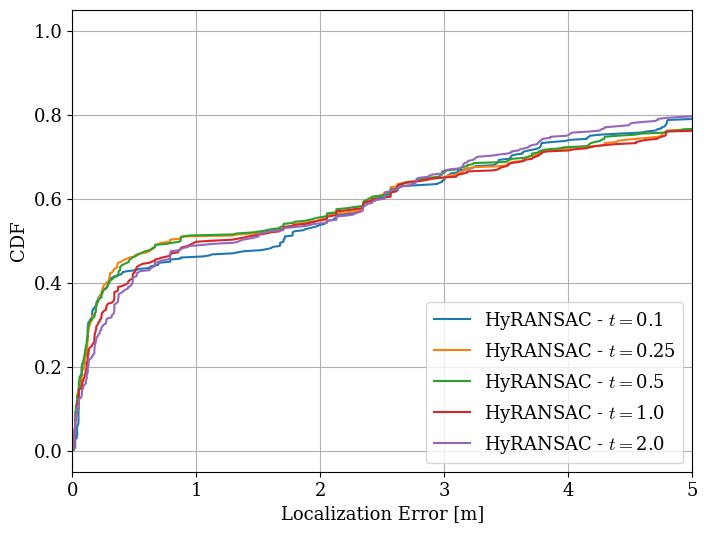

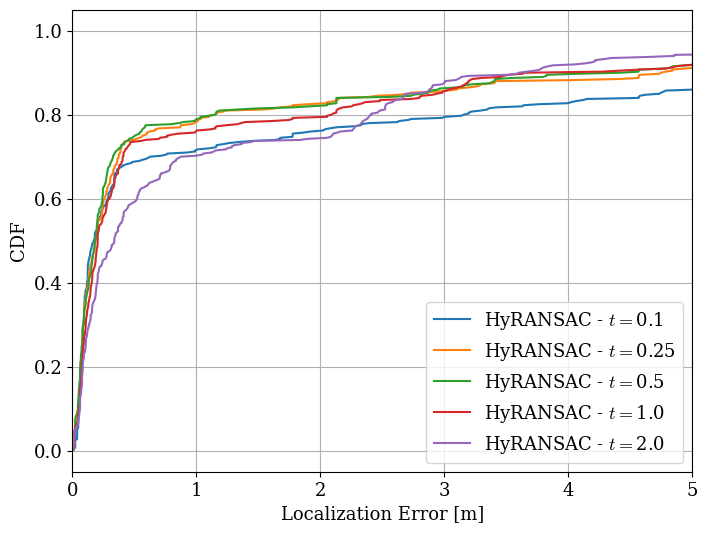

In [47]:
hybrid_ransac_errors_4_plot = [np.sort(np.array(hybrid_ransac_errors_4[t])) for t in range(5)]
hybrid_ransac_errors_6_plot = [np.sort(np.array(hybrid_ransac_errors_6[t])) for t in range(5)]
hybrid_ransac_errors_8_plot = [np.sort(np.array(hybrid_ransac_errors_8[t])) for t in range(5)]


cumulative = np.arange(1, len(hybrid_ransac_errors_4_plot[0]) + 1) / len(hybrid_ransac_errors_4_plot[0])

fig, ax = plt.subplots(figsize=(8, 6))

for t, threshold in enumerate([0.1, 0.25, 0.5, 1.0, 2.0]):
    ax.plot(hybrid_ransac_errors_4_plot[t], cumulative, label=r'HyRANSAC - $t=$'+f'{threshold}')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 5)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
plt.savefig('hybrid_ransac_cdf_large_threshold_rx4.pdf', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))

for t, threshold in enumerate([0.1, 0.25, 0.5, 1.0, 2.0]):
    ax.plot(hybrid_ransac_errors_6_plot[t], cumulative, label=r'HyRANSAC - $t=$'+f'{threshold}')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 5)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
plt.savefig('hybrid_ransac_cdf_large_threshold_rx6.pdf', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))

for t, threshold in enumerate([0.1, 0.25, 0.5, 1.0, 2.0]):
    ax.plot(hybrid_ransac_errors_8_plot[t], cumulative, label=r'HyRANSAC - $t=$'+f'{threshold}')  

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 5)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
plt.savefig('hybrid_ransac_cdf_large_threshold_rx8.pdf', bbox_inches='tight')
plt.show()

In [71]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

hybrid_ransac_errors_fo_4 = []
hybrid_ransac_errors_fo_6 = []
hybrid_ransac_errors_fo_8 = []


for i in range(8):
    for j in range(5):
        for num_rx in [4, 6, 8]:
            filename = f"Large{num_rx}/taps_estimates_{i}_{j}.csv"
            TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

            for iter in range(10):
                
                taus_hat = data[f'{iter}']['delays']
                angles_hat = data[f'{iter}']['angles']

                first_toas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                    first_toas[RX_idx] = first_toa

                first_aoas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

                # Hybrid localization using first path
                HybridLocalizer = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
                position_estimate_hybrid_ransac_fo = HybridLocalizer.localize_ransac_fo(iter=1, ransac_iter=50, threshold=0.5)
                if num_rx == 4:
                    hybrid_ransac_errors_fo_4.append(np.linalg.norm(position_estimate_hybrid_ransac_fo - TX_position[:2]))
                elif num_rx == 6:
                    hybrid_ransac_errors_fo_6.append(np.linalg.norm(position_estimate_hybrid_ransac_fo - TX_position[:2]))
                elif num_rx == 8:
                    hybrid_ransac_errors_fo_8.append(np.linalg.norm(position_estimate_hybrid_ransac_fo - TX_position[:2]))
            
    print(f"Finished processing iter {i}")


Finished processing iter 0
Finished processing iter 1
Finished processing iter 2
Finished processing iter 3
Finished processing iter 4
Finished processing iter 5
Finished processing iter 6
Finished processing iter 7


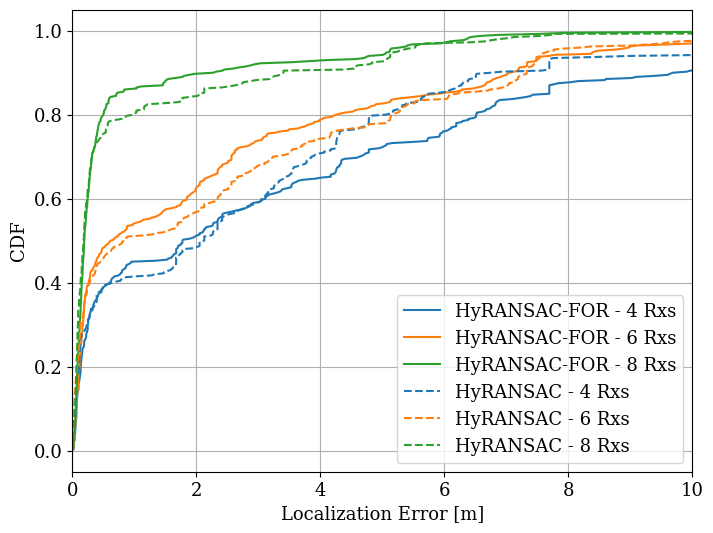

In [75]:
hybrid_ransac_fo_errors_4_plot = np.sort(np.array(hybrid_ransac_errors_fo_4))
hybrid_ransac_fo_errors_6_plot = np.sort(np.array(hybrid_ransac_errors_fo_6))
hybrid_ransac_fo_errors_8_plot = np.sort(np.array(hybrid_ransac_errors_fo_8))


cumulative2 = np.arange(1, len(hybrid_ransac_fo_errors_4_plot) + 1) / len(hybrid_ransac_fo_errors_4_plot)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(hybrid_ransac_fo_errors_4_plot, cumulative2, label='HyRANSAC-FOR - 4 Rxs', color='tab:blue')
ax.plot(hybrid_ransac_fo_errors_6_plot, cumulative2, label='HyRANSAC-FOR - 6 Rxs', linestyle='-', color='tab:orange')
ax.plot(hybrid_ransac_fo_errors_8_plot, cumulative2, label='HyRANSAC-FOR - 8 Rxs', linestyle='-', color='tab:green')
ax.plot(hybrid_ransac_errors_4_plot, cumulative, label='HyRANSAC - 4 Rxs', linestyle='--', color='tab:blue')
ax.plot(hybrid_ransac_errors_6_plot, cumulative, label='HyRANSAC - 6 Rxs', linestyle='--', color='tab:orange')
ax.plot(hybrid_ransac_errors_8_plot, cumulative, label='HyRANSAC - 8 Rxs', linestyle='--', color='tab:green')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 10)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
plt.savefig('hybrid_ransac_for_cdf_large.pdf', bbox_inches='tight')
plt.show()

In [78]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

hybrid_ransac_errors_fo_4_bis = []
hybrid_ransac_errors_fo_6_bis = []
hybrid_ransac_errors_fo_8_bis = []


for i in range(8):
    for j in range(5):
        for num_rx in [4, 6, 8]:
            filename = f"Large{num_rx}/taps_estimates_{i}_{j}.csv"
            TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

            for iter in range(10):
                
                taus_hat = data[f'{iter}']['delays']
                angles_hat = data[f'{iter}']['angles']

                first_toas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                    first_toas[RX_idx] = first_toa

                first_aoas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

                # Hybrid localization using first path
                HybridLocalizer = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
                position_estimate_hybrid_ransac_fo = HybridLocalizer.localize_ransac_fo_strict(iter=50, threshold=0.5)
                if num_rx == 4:
                    hybrid_ransac_errors_fo_4_bis.append(np.linalg.norm(position_estimate_hybrid_ransac_fo - TX_position[:2]))
                elif num_rx == 6:
                    hybrid_ransac_errors_fo_6_bis.append(np.linalg.norm(position_estimate_hybrid_ransac_fo - TX_position[:2]))
                elif num_rx == 8:
                    hybrid_ransac_errors_fo_8_bis.append(np.linalg.norm(position_estimate_hybrid_ransac_fo - TX_position[:2]))


Not enough independent valid paths for RANSAC iteration
Not enough independent valid paths for RANSAC iteration
Not enough independent valid paths for RANSAC iteration


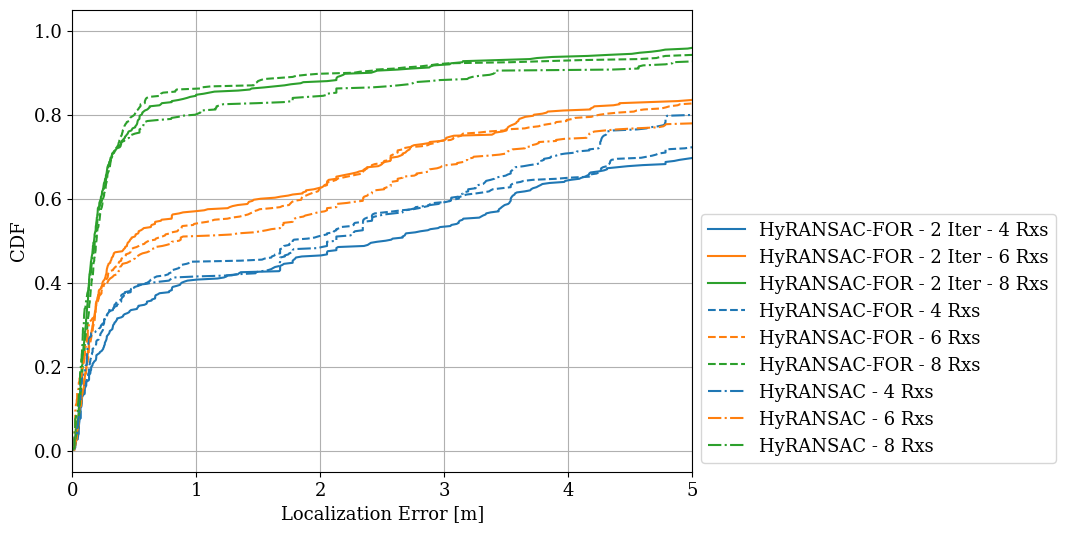

In [79]:
hybrid_ransac_fo_errors_4_bis_plot = np.sort(np.array(hybrid_ransac_errors_fo_4_bis))
hybrid_ransac_fo_errors_6_bis_plot = np.sort(np.array(hybrid_ransac_errors_fo_6_bis))
hybrid_ransac_fo_errors_8_bis_plot = np.sort(np.array(hybrid_ransac_errors_fo_8_bis))


cumulative2 = np.arange(1, len(hybrid_ransac_fo_errors_4_bis_plot) + 1) / len(hybrid_ransac_fo_errors_4_bis_plot)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(hybrid_ransac_fo_errors_4_bis_plot, cumulative2, label='HyRANSAC-FOR - 2 Iter - 4 Rxs', color='tab:blue')
ax.plot(hybrid_ransac_fo_errors_6_bis_plot, cumulative2, label='HyRANSAC-FOR - 2 Iter - 6 Rxs', linestyle='-', color='tab:orange')
ax.plot(hybrid_ransac_fo_errors_8_bis_plot, cumulative2, label='HyRANSAC-FOR - 2 Iter - 8 Rxs', linestyle='-', color='tab:green')
ax.plot(hybrid_ransac_fo_errors_4_plot, cumulative, label='HyRANSAC-FOR - 4 Rxs', linestyle='--', color='tab:blue')
ax.plot(hybrid_ransac_fo_errors_6_plot, cumulative, label='HyRANSAC-FOR - 6 Rxs', linestyle='--', color='tab:orange')
ax.plot(hybrid_ransac_fo_errors_8_plot, cumulative, label='HyRANSAC-FOR - 8 Rxs', linestyle='--', color='tab:green')
ax.plot(hybrid_ransac_errors_4_plot, cumulative, label='HyRANSAC - 4 Rxs', linestyle='-.', color='tab:blue')
ax.plot(hybrid_ransac_errors_6_plot, cumulative, label='HyRANSAC - 6 Rxs', linestyle='-.', color='tab:orange')
ax.plot(hybrid_ransac_errors_8_plot, cumulative, label='HyRANSAC - 8 Rxs', linestyle='-.', color='tab:green')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 5)
ax.set_ylim(-0.05, 1.05)
ax.legend(bbox_to_anchor=(1.0, 0), loc='lower left')
ax.grid()
# plt.savefig('hybrid_ransac_for_cdf_large2.pdf', bbox_inches='tight')
plt.show()

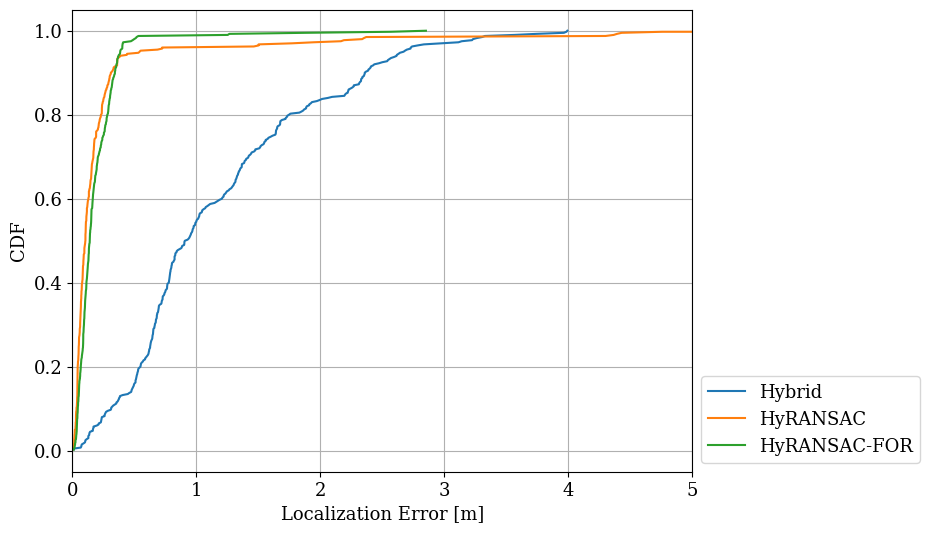

In [69]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(hybrid_errors_8_plot, cumulative, label='Hybrid', linestyle='-')
ax.plot(hybrid_ransac_errors_8_plot, cumulative, label='HyRANSAC', linestyle='-')
ax.plot(hybrid_ransac_fo_errors_8_plot, cumulative, label='HyRANSAC-FOR', linestyle='-')


ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 5)
ax.set_ylim(-0.05, 1.05)
ax.legend(bbox_to_anchor=(1.0, 0), loc='lower left')
ax.grid()
plt.savefig('hybrid_comparison_small.pdf', bbox_inches='tight')
plt.show()